In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\DELL\Desktop\jay\AB Testing\Dataset\ab_testing.csv")
df.head(10)

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,3,424,No,Mobile,Northern Ireland
1,11682,A,9,342,No,Mobile,Scotland
2,19825,A,2,396,No,Desktop,Northern Ireland
3,16080,B,4,318,No,Desktop,Wales
4,18851,A,1,338,Yes,Desktop,Scotland
5,13134,B,2,93,No,Desktop,Scotland
6,16702,A,5,106,No,Mobile,Northern Ireland
7,10041,B,9,292,No,Mobile,Northern Ireland
8,13191,B,8,434,No,Desktop,Northern Ireland
9,14427,B,12,271,No,Desktop,England


# A/B Testing: Website Conversion Analysis

## Business Context
Testing a new website version (Group B) against the current version (Group A) 
to determine if it improves user conversion.

## Hypotheses
- H0: Conversion rate of Group B = Conversion rate of Group A
- H1: Conversion rate of Group B ≠ Conversion rate of Group A

## Significance Level
alpha = 0.05 (95% confidence)

## Decision Rule
- p < 0.05 → reject H0 → treatment has significant effect
- p >= 0.05 → fail to reject H0 → not enough evidence

In [3]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate User IDs:", df['User ID'].duplicated().sum())
print("\nGroup balance:\n", df['Group'].value_counts())

Shape: (5000, 7)

Missing values:
 User ID       0
Group         0
Page Views    0
Time Spent    0
Conversion    0
Device        0
Location      0
dtype: int64

Duplicate User IDs: 0

Group balance:
 Group
A    2519
B    2481
Name: count, dtype: int64


Group
A    0.053990
B    0.140669
Name: Conversion, dtype: float64


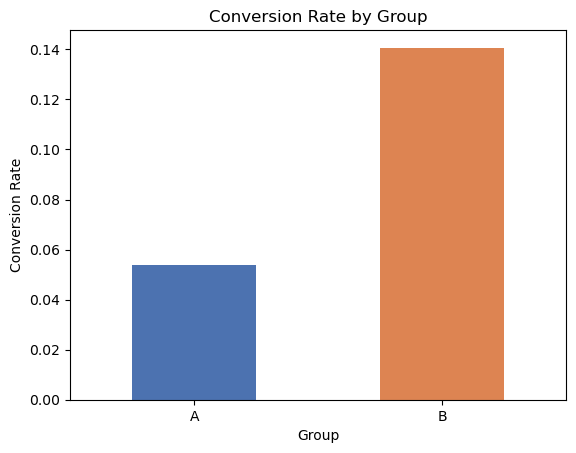

In [4]:
conv_rate = df.groupby('Group')['Conversion'].apply(lambda x: (x=='Yes').mean())
print(conv_rate)

conv_rate.plot(kind='bar', color=['#4C72B0','#DD8452'])
plt.title('Conversion Rate by Group')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=0)
plt.show()

In [5]:
print("Page Views mean by group:\n", df.groupby('Group')['Page Views'].mean())
print("\nTime Spent mean by group:\n", df.groupby('Group')['Time Spent'].mean())
print("\nDevice split by group:\n", pd.crosstab(df['Group'], df['Device'], normalize='index'))
print("\nLocation split by group:\n", pd.crosstab(df['Group'], df['Location'], normalize='index'))

Page Views mean by group:
 Group
A    7.581580
B    7.492946
Name: Page Views, dtype: float64

Time Spent mean by group:
 Group
A    241.733227
B    243.303910
Name: Time Spent, dtype: float64

Device split by group:
 Device   Desktop    Mobile
Group                     
A       0.493847  0.506153
B       0.521564  0.478436

Location split by group:
 Location   England  Northern Ireland  Scotland     Wales
Group                                                   
A         0.240572          0.243748  0.265979  0.249702
B         0.257960          0.253124  0.246272  0.242644


In [6]:
p1 = df[df['Group']=='A']['Conversion'].eq('Yes').mean()
p2 = df[df['Group']=='B']['Conversion'].eq('Yes').mean()

alpha = 0.05
power = 0.80
z_alpha = stats.norm.ppf(1 - alpha/2)
z_beta = stats.norm.ppf(power)

p_bar = (p1 + p2) / 2
effect_size = abs(p2 - p1)

n_required = ((z_alpha*np.sqrt(2*p_bar*(1-p_bar)) + z_beta*np.sqrt(p1*(1-p1)+p2*(1-p2)))**2) / (effect_size**2)

print(f"Required sample size per group: {n_required:.0f}")
print(f"Actual sample size - A: {(df.Group=='A').sum()}, B: {(df.Group=='B').sum()}")

Required sample size per group: 182
Actual sample size - A: 2519, B: 2481


In [7]:
n1, n2 = (df.Group=='A').sum(), (df.Group=='B').sum()
x1 = df[df.Group=='A']['Conversion'].eq('Yes').sum()
x2 = df[df.Group=='B']['Conversion'].eq('Yes').sum()

p_pool = (x1 + x2) / (n1 + n2)
se = np.sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2))
z_stat = (p2 - p1) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

se_diff = np.sqrt(p1*(1-p1)/n1 + p2*(1-p2)/n2)
ci_low = (p2-p1) - 1.96*se_diff
ci_high = (p2-p1) + 1.96*se_diff

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"95% CI for difference (B-A): [{ci_low:.4f}, {ci_high:.4f}]")

Z-statistic: 10.3545
P-value: 0.000000
95% CI for difference (B-A): [0.0704, 0.1030]


In [8]:
# T-test: Time Spent
t_stat, t_p = stats.ttest_ind(df[df.Group=='A']['Time Spent'], df[df.Group=='B']['Time Spent'])
print(f"Time Spent t-test: t={t_stat:.4f}, p={t_p:.4f}")

# T-test: Page Views
t_stat2, t_p2 = stats.ttest_ind(df[df.Group=='A']['Page Views'], df[df.Group=='B']['Page Views'])
print(f"Page Views t-test: t={t_stat2:.4f}, p={t_p2:.4f}")

# Chi-square: Device vs Conversion
contingency = pd.crosstab(df['Device'], df['Conversion'])
chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)
print(f"Device vs Conversion chi-square: chi2={chi2:.4f}, p={chi_p:.4f}")

Time Spent t-test: t=-0.4695, p=0.6387
Page Views t-test: t=0.7790, p=0.4360
Device vs Conversion chi-square: chi2=0.3642, p=0.5462


In [9]:
seg_device = df.groupby(['Group','Device'])['Conversion'].apply(lambda x: (x=='Yes').mean()).unstack()
print("Conversion rate by Group x Device:\n", seg_device)

seg_location = df.groupby(['Group','Location'])['Conversion'].apply(lambda x: (x=='Yes').mean()).unstack()
print("\nConversion rate by Group x Location:\n", seg_location)

Conversion rate by Group x Device:
 Device   Desktop    Mobile
Group                     
A       0.058682  0.049412
B       0.139104  0.142376

Conversion rate by Group x Location:
 Location   England  Northern Ireland  Scotland     Wales
Group                                                   
A         0.069307          0.050489  0.049254  0.047695
B         0.146875          0.114650  0.150573  0.151163


## Business Recommendation

**Result:** Group B (treatment) achieved a conversion rate of 14.07% vs 5.39% 
for Group A (control) — a statistically significant lift of 7.04–10.30 
percentage points (95% CI), p < 0.001.

**Robustness checks:**
- Groups were well-balanced on Page Views, Time Spent, Device, and Location 
  prior to treatment, ruling out confounding.
- The effect is consistent across all Device types and all Locations — 
  no segment is driving the result disproportionately.
- Actual sample size (2,519 / 2,481) far exceeded the minimum required 
  (182 per group), so this is a high-confidence result, not an underpowered fluke.

**Recommendation:** Roll out Group B's version to all users. 
The lift is large, statistically robust, and consistent across all major 
user segments. 

**Suggested next step:** Since the estimated lift could be as low as 7pp 
or as high as 10.3pp, quantify the projected revenue/signup impact using 
the lower bound of the CI (7pp) as a conservative estimate before 
finalizing the rollout business case.